# Experiment — July's methodology on August's values

**Standalone. Nothing here is wired, and nothing in the production pipeline was modified.**

## The question

August's canonical mobile forecast switched the `m` overlay to **anchor-and-subtract** on the new
UAC + Meta query. What would the number have been if we had kept **July's methodology** instead?

July carried the prior cycle's delivered curve forward, moved only by the change in the marketing
team's own Total-Paid-DAU outlook between the two source deliveries
(`data-official/2026-07/marketing/build_lift.py`):

    L_july(d) = L_june(d) + [csv_jul_total(d) − csv_jun_total(d)]

Applying that same rule one cycle on, with August's source in place of July's:

    L_aug_JM(d) = L_july_delivered(d) + [aug_total(d) − jul_total(d)],   0 before campaign launch

Built by `build_july_methodology_curve.py` → `marketing_lift_model.july_methodology.2026-07-28.parquet`.
**Dec-15 lift 830,360**, against the canonical anchor-and-subtract curve's 637,227 and July's
delivered 778,880.

## Two properties of the methodology worth naming

1. **The whole Meta contribution enters as incremental delta.** July's source predates Meta
   entirely, so `aug_total − jul_total` books all of it as new. That is what the rule does, not a
   choice made here.
2. **It inherits everything upstream.** July's curve inherits June's curve, which rests on a single
   45-day empirical gap measurement ending 2026-05-20. Under this rule August is the third cycle
   of outlook deltas stacked on that one measurement — the property anchor-and-subtract was adopted
   to escape.

It also faithfully reproduces one inherited defect: July's curve has a one-day −63,955 spike at
2026-04-06 (its builder zeroed only *strictly* before campaign launch), which survives here. One
day, in history, inside the training window.

## What this notebook does

Reproduces the canonical notebook's `[plot-mobile]` chart — same 28d-MA convention, same
seam-matched `display_ma`, same Win10 headwind, same stakeholder markers — with the experiment
curve added as a fourth line. The plotting and series logic is **copied, not imported**, so this
notebook cannot perturb the canonical one and will not drift if the canonical one changes.

Actuals come from the forecast parquet's `training` rows rather than a BigQuery query
(`scripts/verify_training_rows_are_actuals.py` confirms they are equal), which keeps this notebook
runnable offline and saves ~1TB of scan.


In [1]:
# [setup]
# Standalone: this notebook copies the canonical notebook's series/plot conventions rather than
# importing them, so it cannot perturb the canonical run and will not silently drift with it.
import glob
import json
import os
import subprocess
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

os.chdir(subprocess.run(["git", "rev-parse", "--show-toplevel"],
                        capture_output=True, text=True).stdout.strip())
sys.path.insert(0, "src")

from mozaic_daily.adjustments import load_forecast  # noqa: E402
from mozaic_daily.seam_ma import display_ma  # noqa: E402

EXP_DIR = "data-official/2026-08/marketing/experiment_july_methodology"

# Three mobile forecasts, all at the same 2026-07-28 seam, differing ONLY in the `m` lift curve.
CANONICAL_AUGUST = ("data-official/2026-08/mobile_uac_meta_2026-07-28/"
                    "cps0.035_thresh055_recent13_cpr0.75_ncp25_clip0.6_sps0.1/"
                    "mozaic_daily_forecast.2026-07-28.gm-D.adj-m.parquet")
EXPERIMENT_AUGUST = f"{EXP_DIR}/forecast/mozaic_daily_forecast.2026-07-28.gm-D.adj-m.parquet"
PRIOR_JULY = ("data-official/2026-07/mobile_refresh_2026-07-06/"
              "cps0.035_thresh055_recent13_cpr0.75_ncp25_clip0.6/"
              "mozaic_daily_forecast.2026-07-06.gm-D.adj-m.parquet")

# Display-layer Win10 headwind (`h`). Each forecast is adjusted from ITS OWN seam forward: using the
# current seam for July's curve would leave 07-06..07-27 unadjusted, three weeks where it genuinely
# was a forecast, and understate the prior line.
ADJUSTMENTS_DIR = "data-official/2026-08/adjustments"
PREV_ADJUSTMENTS_DIR = "data-official/2026-07/adjustments"

PLOTS_DIR = f"{EXP_DIR}/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")
FORECAST_START = pd.Timestamp("2026-07-28")
PREV_FORECAST_START = pd.Timestamp("2026-07-06")
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")
MA_WINDOW = 28

# Reused from the canonical notebook for scale comparability. These are June-cycle aspirational
# markers carried into July -- NOT August targets.
STAKEHOLDER_MOBILE_LOW = 17_019_424
STAKEHOLDER_MOBILE_BASELINE = 17_522_795
STAKEHOLDER_MOBILE_STRETCH = 17_742_615

# Pinned from the canonical notebook's [mobile-dec15]; asserted below so this notebook fails loudly
# if it ever stops reproducing the canonical numbers it is being compared against.
JULY_DELIVERED_MOBILE_DEC15 = 17_923_869
CANONICAL_AUGUST_MOBILE_DEC15 = 17_864_732

for label, path in [("canonical August", CANONICAL_AUGUST), ("experiment August", EXPERIMENT_AUGUST),
                    ("prior July", PRIOR_JULY)]:
    print(f"{label:20s} exists={os.path.exists(path)}  {path}")


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


canonical August     exists=True  data-official/2026-08/mobile_uac_meta_2026-07-28/cps0.035_thresh055_recent13_cpr0.75_ncp25_clip0.6_sps0.1/mozaic_daily_forecast.2026-07-28.gm-D.adj-m.parquet
experiment August    exists=True  data-official/2026-08/marketing/experiment_july_methodology/forecast/mozaic_daily_forecast.2026-07-28.gm-D.adj-m.parquet
prior July           exists=True  data-official/2026-07/mobile_refresh_2026-07-06/cps0.035_thresh055_recent13_cpr0.75_ncp25_clip0.6/mozaic_daily_forecast.2026-07-06.gm-D.adj-m.parquet


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# [helpers]
# Copied from the canonical notebook's [helpers] so this notebook is self-contained. Kept verbatim
# in behaviour -- if these diverge, the comparison against the canonical numbers stops being valid,
# which is what the assertions in [compute-series] are there to catch.


def render_adjustment(spec, date_index):
    """Convert a single adjustment spec to net DAU Series for desktop and mobile."""
    idx = pd.DatetimeIndex(date_index)
    desktop = pd.Series(0.0, index=idx)
    mobile = pd.Series(0.0, index=idx)

    if spec["type"] == "linear_ramp":
        start = pd.Timestamp(spec["start_date"])
        anchor = pd.Timestamp(spec["anchor_date"])
        total_days = (anchor - start).days
        elapsed = np.maximum(0, (idx - start).days)
        desktop[:] = spec.get("desktop_dau", 0) * elapsed / total_days
        mobile[:] = spec.get("mobile_dau", 0) * elapsed / total_days

    elif spec["type"] == "step":
        start = pd.Timestamp(spec["start_date"])
        end = pd.Timestamp(spec["end_date"]) if "end_date" in spec else idx[-1]
        mask = (idx >= start) & (idx <= end)
        desktop[mask] = spec.get("desktop_dau", 0)
        mobile[mask] = spec.get("mobile_dau", 0)

    elif spec["type"] == "daily_series":
        for date_str, values in spec["series"].items():
            date = pd.Timestamp(date_str)
            if date in idx:
                loc = idx.get_loc(date)
                desktop.iloc[loc] = values.get("desktop_dau", 0)
                mobile.iloc[loc] = values.get("mobile_dau", 0)

    return {"desktop": desktop, "mobile": mobile}


def load_adjustments(adjustments_dir, date_index):
    """Sum all adjustment components in a directory into net desktop/mobile DAU series."""
    idx = pd.DatetimeIndex(date_index)
    desktop_total = pd.Series(0.0, index=idx)
    mobile_total = pd.Series(0.0, index=idx)
    found = sorted(glob.glob(f"{adjustments_dir}/*.json"))
    if not found:
        raise FileNotFoundError(
            f"No adjustment specs in {adjustments_dir}. An empty dir would silently publish a "
            f"pre-headwind number."
        )
    for path in found:
        with open(path) as f:
            spec = json.load(f)
        rendered = render_adjustment(spec, idx)
        desktop_total += rendered["desktop"]
        mobile_total += rendered["mobile"]
    return {"desktop": desktop_total, "mobile": mobile_total}


def apply_net_adjustment(ma_series, net_adjustments, platform, forecast_start):
    """Apply the net display-layer adjustment from `forecast_start` forward only."""
    result = ma_series.copy()
    forecast_mask = result.index >= forecast_start
    adj = net_adjustments[platform].reindex(result.index, fill_value=0.0)
    result[forecast_mask] += adj[forecast_mask]
    return result


def load_all_level_dau(path, *, require_state):
    """Load a validated forecast parquet, return World(ALL) ALL-MOBILE daily DAU with data_type."""
    df, meta = load_forecast(path, require_state=require_state)
    mask = (
        (df["country"] == "ALL")
        & (df["segment"] == "{}")
        & (df["data_source"] == "glean_mobile")
        & (df["app_name"] == "ALL MOBILE")
    )
    result = df.loc[mask, ["target_date", "dau", "data_type"]].copy()
    result["target_date"] = pd.to_datetime(result["target_date"])
    return result.sort_values("target_date").reset_index(drop=True), meta


def daily_to_28ma(dates, values):
    """Plain 28-day trailing moving average, date-indexed."""
    s = pd.Series(np.asarray(values), index=pd.to_datetime(np.asarray(dates)))
    return s.sort_index().rolling(MA_WINDOW).mean()


def millions_formatter(x, pos):
    # Two decimals so adjacent ~0.5M-spaced ticks stay distinct (16.50M vs 17.00M) rather than
    # collapsing to identical whole-million labels.
    return f"{x / 1e6:.2f}M"


def clip_display(s):
    return s[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)].dropna()


def clip_forecast_only(s, forecast_start):
    return s[(s.index >= forecast_start) & (s.index <= DISPLAY_END)].dropna()


In [3]:
# [compute-series]
# Same convention as the canonical notebook: forecast curves use the variance-matched display_ma
# (seam-smoothed), actuals use the plain trailing MA, and the Win10 headwind is applied to the MA
# from each forecast's own seam forward.

canonical_raw, canonical_meta = load_all_level_dau(CANONICAL_AUGUST, require_state=["m"])
experiment_raw, experiment_meta = load_all_level_dau(EXPERIMENT_AUGUST, require_state=["m"])
prior_raw, prior_meta = load_all_level_dau(PRIOR_JULY, require_state=["m"])

canonical_ma_raw = display_ma(canonical_raw["target_date"], canonical_raw["dau"], FORECAST_START)
experiment_ma_raw = display_ma(experiment_raw["target_date"], experiment_raw["dau"], FORECAST_START)
prior_ma_raw = display_ma(prior_raw["target_date"], prior_raw["dau"], PREV_FORECAST_START)

net_adjustments = load_adjustments(ADJUSTMENTS_DIR, canonical_ma_raw.index)
prev_net_adjustments = load_adjustments(PREV_ADJUSTMENTS_DIR, canonical_ma_raw.index)

mobile_ma = apply_net_adjustment(canonical_ma_raw, net_adjustments, "mobile", FORECAST_START)
experiment_ma = apply_net_adjustment(experiment_ma_raw, net_adjustments, "mobile", FORECAST_START)
prev_mobile_ma = apply_net_adjustment(prior_ma_raw, prev_net_adjustments, "mobile",
                                      PREV_FORECAST_START)

# Actuals from the canonical parquet's training rows. verify_training_rows_are_actuals.py confirms
# these equal raw BigQuery actuals, so this avoids a ~1TB scan and keeps the notebook offline-runnable.
actual_rows = canonical_raw[canonical_raw["data_type"] == "training"]
mobile_actual_ma = daily_to_28ma(actual_rows["target_date"], actual_rows["dau"])

# This notebook copies the canonical notebook's logic rather than importing it. These assertions are
# the guard against that copy drifting: if either reproduction breaks, the comparison is invalid and
# every delta below is junk.
july_drift = prev_mobile_ma.get(MEASUREMENT_DATE) - JULY_DELIVERED_MOBILE_DEC15
assert abs(july_drift) < 1000, (
    f"July delivered mobile Dec-15 does not reproduce (drift {july_drift:+,.0f}). The copied series "
    f"logic has diverged from the canonical notebook."
)
canonical_drift = mobile_ma.get(MEASUREMENT_DATE) - CANONICAL_AUGUST_MOBILE_DEC15
assert abs(canonical_drift) < 1, (
    f"Canonical August mobile Dec-15 does not reproduce (drift {canonical_drift:+,.0f}). The copied "
    f"series logic has diverged from the canonical notebook."
)
print(f"Reproduction checks pass — July drift {july_drift:+,.0f}, canonical drift {canonical_drift:+,.0f}\n")

series_at_kpi = {
    "July 2026 delivered": prev_mobile_ma.get(MEASUREMENT_DATE),
    "August canonical (anchor-and-subtract)": mobile_ma.get(MEASUREMENT_DATE),
    "August experiment (July methodology)": experiment_ma.get(MEASUREMENT_DATE),
}
print(f"Mobile Dec-15 2026, 28d MA (post-headwind)\n{'-' * 62}")
for name, value in series_at_kpi.items():
    print(f"{name:<40s} {value:>18,.0f}")

exp_vs_canon = series_at_kpi["August experiment (July methodology)"] - series_at_kpi["August canonical (anchor-and-subtract)"]
exp_vs_july = series_at_kpi["August experiment (July methodology)"] - series_at_kpi["July 2026 delivered"]
print(f"\nexperiment vs canonical August: {exp_vs_canon:+,.0f} DAU")
print(f"experiment vs July delivered:   {exp_vs_july:+,.0f} DAU")
print(f"\nlift-curve difference at Dec-15 was 830,360 - 637,227 = +193,133;")
print(f"realised KPI effect is {exp_vs_canon / 193_133 * 100:.0f}% of it "
      f"(the overlay is bidirectional and absorbs the rest).")


Reproduction checks pass — July drift -0, canonical drift +0

Mobile Dec-15 2026, 28d MA (post-headwind)
--------------------------------------------------------------
July 2026 delivered                              17,923,869
August canonical (anchor-and-subtract)           17,864,732
August experiment (July methodology)             17,903,366

experiment vs canonical August: +38,633 DAU
experiment vs July delivered:   -20,503 DAU

lift-curve difference at Dec-15 was 830,360 - 637,227 = +193,133;
realised KPI effect is 20% of it (the overlay is bidirectional and absorbs the rest).


saved: data-official/2026-08/marketing/experiment_july_methodology/plots/mobile_july_methodology_experiment.png


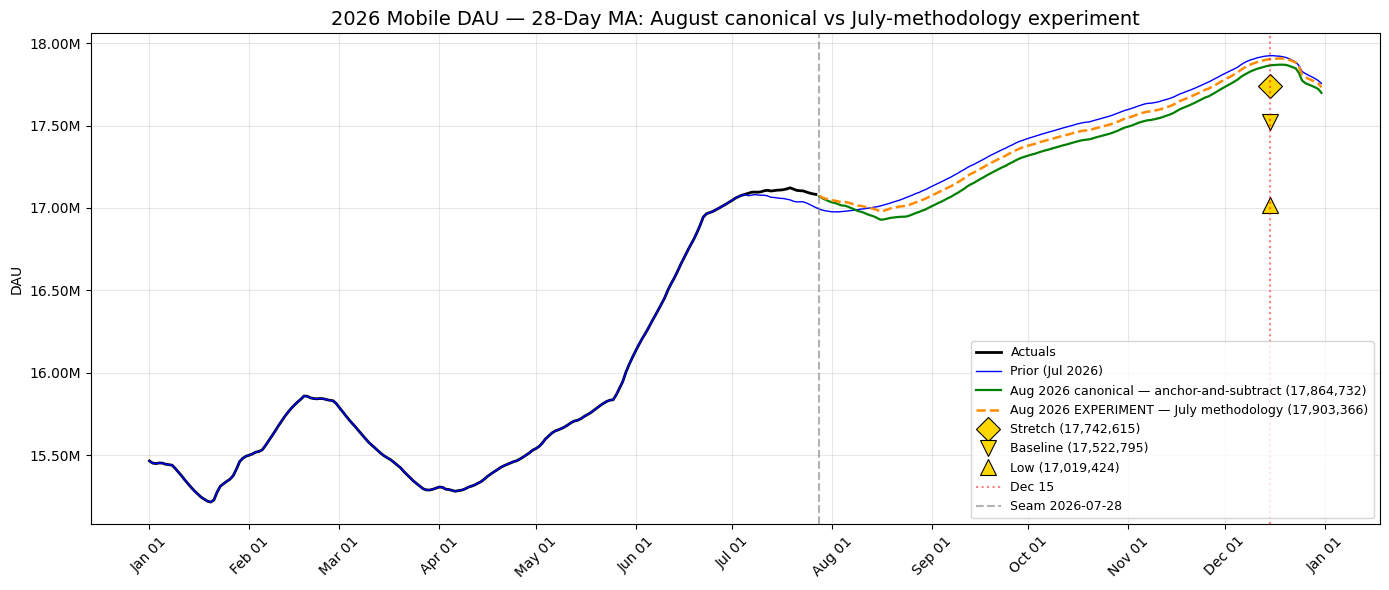

In [4]:
# [plot-mobile-experiment]
# The canonical notebook's [plot-mobile] chart with the experiment curve added as a fourth line.
# Same conventions throughout: 28d MA, seam-matched display_ma for forecasts, plain MA for actuals,
# Win10 headwind applied, June-cycle stakeholder markers for scale.
#
# The experiment line is drawn dashed so it reads as a counterfactual rather than a candidate.


def render_mobile_experiment_plot(*, title, savename, show_prior=True):
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(clip_display(mobile_actual_ma), label="Actuals", color="black", linewidth=2)
    if show_prior:
        ax.plot(clip_display(prev_mobile_ma), label="Prior (Jul 2026)", color="blue", linewidth=1)
    ax.plot(clip_forecast_only(mobile_ma, FORECAST_START),
            label=f"Aug 2026 canonical — anchor-and-subtract ({mobile_ma.get(MEASUREMENT_DATE):,.0f})",
            color="green", linewidth=1.6)
    ax.plot(clip_forecast_only(experiment_ma, FORECAST_START),
            label=f"Aug 2026 EXPERIMENT — July methodology ({experiment_ma.get(MEASUREMENT_DATE):,.0f})",
            color="darkorange", linewidth=1.8, linestyle="--")
    for value, marker, label in [
        (STAKEHOLDER_MOBILE_STRETCH, "D", "Stretch"),
        (STAKEHOLDER_MOBILE_BASELINE, "v", "Baseline"),
        (STAKEHOLDER_MOBILE_LOW, "^", "Low"),
    ]:
        ax.plot(MEASUREMENT_DATE, value, marker=marker, color="gold", markersize=12,
                markeredgecolor="black", markeredgewidth=0.8, linestyle="None",
                label=f"{label} ({value:,})")
    ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
    ax.axvline(FORECAST_START, color="grey", linestyle="--", alpha=0.6,
               label=f"Seam {FORECAST_START.date()}")
    ax.set_title(title, fontsize=14)
    ax.set_ylabel("DAU")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.legend(loc="lower right", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    out = f"{PLOTS_DIR}/{savename}"
    fig.savefig(out, dpi=130)
    print(f"saved: {out}")
    plt.show()


render_mobile_experiment_plot(
    title="2026 Mobile DAU — 28-Day MA: August canonical vs July-methodology experiment",
    savename="mobile_july_methodology_experiment.png")
